<a href="https://colab.research.google.com/github/mabitha-7/mlops_training/blob/main/MLOPS_TRAINING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LINEAR REGRESSION

In [ ]:
import pandas as pd
df = pd.read_csv("/content/worker_safety_text_dataset_1000 (1).csv")
print(df.head())

   Report_ID    Incident_Type  \
0  SAFE-0001     Mask Missing   
1  SAFE-0002   Helmet Missing   
2  SAFE-0003     Mask Missing   
3  SAFE-0004  Emergency Alarm   
4  SAFE-0005   Helmet Missing   

                                         Description Risk_Level       Status  \
0  Employee entered a restricted zone without aut...        Low     Resolved   
1  Protective gloves were not used during equipme...   Moderate         Open   
2  Worker observed without proper PPE near the as...        Low  In Progress   
3  Machine produced abnormal sounds during operat...   Moderate         Open   
4  Safety helmet violation identified in construc...        Low         Open   

        Location        Reported_By  
0  Factory Floor  Christian Mercado  
1  Assembly Line       Kevin Brooks  
2   Loading Dock      Amanda Cortez  
3   Storage Area        Nicole Dyer  
4   Loading Dock     Donald Ramirez  


In [ ]:
risk_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}
df["Risk_Score"] = df["Risk_Level"].map(risk_mapping)
print(df[["Risk_Level", "Risk_Score"]].head())

  Risk_Level  Risk_Score
0        Low           1
1   Moderate           2
2        Low           1
3   Moderate           2
4        Low           1


In [ ]:
X = df["Description"]
y = df["Risk_Score"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)
print(predictions[:10])

[1.97222247 1.93975913 1.84705836 1.97222247 2.00000044 2.13793111
 1.97222247 2.01234483 1.84705836 1.97222247]


In [ ]:
from sklearn.metrics import r2_score
score = r2_score(y_test, predictions)
print("R2 Score:", score)

R2 Score: -0.025952279696987768


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv("worker_safety_text_dataset_1000 (1).csv")
risk_mapping = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}
df["Risk_Score"] = df["Risk_Level"].map(risk_mapping)
X = df["Description"]
y = df["Risk_Score"]
vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = r2_score(y_test, predictions)
print("R2 Score:", score)
print("Predictions:")
print(predictions[:10])

R2 Score: -0.025952279696987768
Predictions:
[1.97222247 1.93975913 1.84705836 1.97222247 2.00000044 2.13793111
 1.97222247 2.01234483 1.84705836 1.97222247]


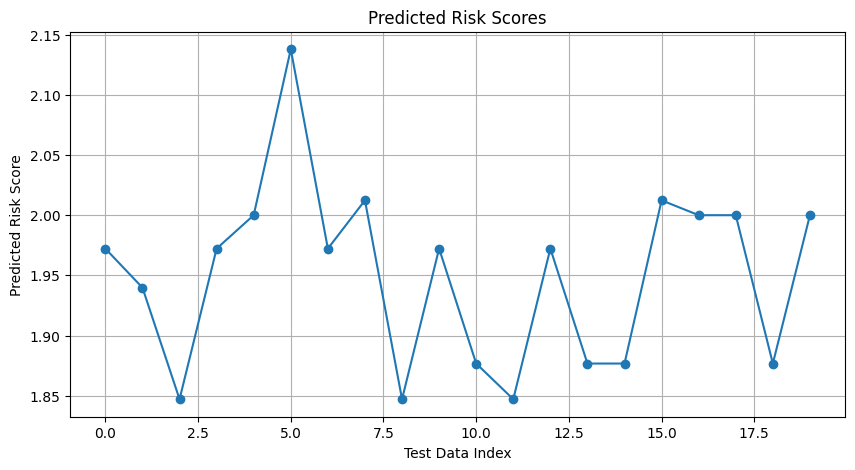

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(predictions[:20], marker='o')
plt.title("Predicted Risk Scores")
plt.xlabel("Test Data Index")
plt.ylabel("Predicted Risk Score")
plt.grid(True)
plt.show()

MULTI LINEARR REGRESSION


   Report_ID    Incident_Type  \
0  SAFE-0001     Mask Missing   
1  SAFE-0002   Helmet Missing   
2  SAFE-0003     Mask Missing   
3  SAFE-0004  Emergency Alarm   
4  SAFE-0005   Helmet Missing   

                                         Description Risk_Level       Status  \
0  Employee entered a restricted zone without aut...        Low     Resolved   
1  Protective gloves were not used during equipme...   Moderate         Open   
2  Worker observed without proper PPE near the as...        Low  In Progress   
3  Machine produced abnormal sounds during operat...   Moderate         Open   
4  Safety helmet violation identified in construc...        Low         Open   

        Location        Reported_By  
0  Factory Floor  Christian Mercado  
1  Assembly Line       Kevin Brooks  
2   Loading Dock      Amanda Cortez  
3   Storage Area        Nicole Dyer  
4   Loading Dock     Donald Ramirez  

Predictions:
[0.96381647 0.93841235 0.94365122 1.00414696 1.04124829 0.99489859
 0.98136228

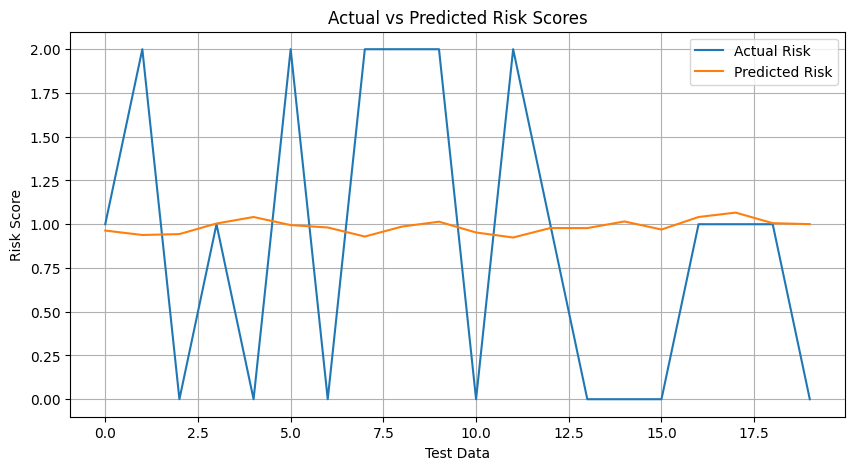

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
df = pd.read_csv("/content/worker_safety_text_dataset_1000 (1).csv")
print(df.head())
le_incident = LabelEncoder()
le_status = LabelEncoder()
le_location = LabelEncoder()
le_risk = LabelEncoder()
df["Incident_Type_encoded"] = le_incident.fit_transform(df["Incident_Type"])
df["Status_encoded"] = le_status.fit_transform(df["Status"])
df["Location_encoded"] = le_location.fit_transform(df["Location"])
df["Risk_Score"] = le_risk.fit_transform(df["Risk_Level"])
X = df[[
    "Incident_Type_encoded",
    "Status_encoded",
    "Location_encoded"
]]
y = df["Risk_Score"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print("\nPredictions:")
print(predictions[:10])
score = r2_score(y_test, predictions)
print("\nR2 Score:", score)
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:20], label="Actual Risk")
plt.plot(predictions[:20], label="Predicted Risk")
plt.title("Actual vs Predicted Risk Scores")
plt.xlabel("Test Data")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True)
plt.show()

IMPORT THE REQUIRED PACKAGE FOR SAVE THE MODEL IN PICKLE

In [3]:
import pickle

SAVE THE MODEL

In [4]:
with open("safehands_model.pkl", "wb") as file:
    pickle.dump(model, file)

DOWNLOAD THE DATASET

In [5]:
from google.colab import files
files.download("safehands_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

IMPORT THE JOBLIB PACKAGE

In [6]:
import joblib

CONVERT THE MODEL

In [7]:
joblib.dump(model, "safehands_model.joblib")

['safehands_model.joblib']

DOWNLOAD THE MODEL

In [8]:
files.download("safehands_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>